Auteurs : Juan Carlos PAJARES, Jordy SALTOS

# Credit Score Classification

The objective of this project is to develop a predictive model capable of assessing the creditworthiness of new loan applicants. The model outputs a binary prediction—Good (low-risk borrower) or Bad (high-risk borrower)—and will be integrated into the loan approval workflow so that each new application receives an automated risk assessment.

Business Objective :

- Reduce financial losses by distinguishing borrowers who are likely to repay (Good) from those who present high default risk (Bad).


Intended Use of the Model :

- Each incoming loan application is processed by the model, which returns a Good/Bad prediction.

- The output informs acceptance, rejection.

Problem Framing :

- Learning type: Supervised learning — historical loan data contains labeled outcomes (Good or Bad).

- Task type: Binary classification — predict the probability that a new applicant will remain “Good” in the future.

- Learning setup: Offline batch learning — the model is trained on historical data and periodically retrained as new information becomes available.

State-of-the-art methods :

According to the recent survey by Shi et al. (2022), credit scoring has progressively shifted from traditional statistical methods toward machine learning and deep learning approaches.
The authors report that deep learning models generally achieve higher predictive performance than classical machine learning techniques, although their adoption remains limited in practice.
The study also confirms that ensemble methods consistently outperform single models, making them strong and reliable baselines for credit risk classification. Detailed results are presented in the accompanying slides.

Comparable Problems :

- Multi-class credit scoring (Good/Standard/Bad): although the original dataset includes three categories, Standard and Bad were merged to focus on a clearer Good/Bad separation.

- Fraud detection in payments — also a binary risk classification task.

- Customer churn prediction — estimating the likelihood of a customer leaving, structurally similar to predicting default risk.

Performance Measure :

- The main evaluation metric is the F1-score, chosen because it balances precision and recall.

- Since both false positives (accepting a risky borrower) and false negatives (rejecting a good borrower) have business impacts, maximizing F1 ensures strong performance on both dimensions.

## Import Libraries

In [ ]:
import matplotlib.pyplot as plt
import time
import numpy as np
import pandas as pd
import sklearn
from matplotlib.colors import ListedColormap
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn import (
    decomposition,
    linear_model,
    model_selection,
    naive_bayes,
    pipeline,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
import warnings
#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier

## Data Preprocessing



We import the dataset that we are going to use.

Dataset must be downloaded manually from Kaggle : https://www.kaggle.com/datasets/parisrohan/credit-score-classification/data?select=train.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
df_train=pd.read_csv("train.csv",low_memory=False)


We analyzed the variables to determine how much missing data each one contains, in order to make an informed decision about which variables are worth cleaning and which variables we should exclude from our study.

In [ ]:
print(df_train.isna().sum()[df_train.isna().sum() >0])

Name                        9985
Monthly_Inhand_Salary      15002
Type_of_Loan               11408
Num_of_Delayed_Payment      7002
Num_Credit_Inquiries        1965
Credit_History_Age          9030
Amount_invested_monthly     4479
Monthly_Balance             1200
dtype: int64


Once we identified the number of NaN values in each variable, we decided that if a variable contained more than 5,000 missing entries, we would discard that information. We considered that such a high loss of data made it unsuitable to be treated as a truly explanatory variable.
Additionally, we decided to remove variables that served solely to identify customers and did not provide any useful information for the study such as name, SSN, ID, ...

In [ ]:
df_train = df_train.drop(['ID','SSN','Type_of_Loan','Credit_History_Age', "Monthly_Inhand_Salary","Name"], axis=1)

We selected our numerical variables and converted all the data in these columns into numeric values. Any remaining entries containing symbols or non-numeric characters were transformed into NaN values.

In [ ]:

numeric_cols = ['Age','Annual_Income',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
       'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month','Num_of_Delayed_Payment','Amount_invested_monthly',
       'Monthly_Balance']
print(df_train[numeric_cols].head(10))
for col in numeric_cols:
    df_train[col] = pd.to_numeric(df_train[col], errors='coerce')



    Age Annual_Income  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  \
0    23      19114.12                  3                4              3   
1    23      19114.12                  3                4              3   
2  -500      19114.12                  3                4              3   
3    23      19114.12                  3                4              3   
4    23      19114.12                  3                4              3   
5    23      19114.12                  3                4              3   
6    23      19114.12                  3                4              3   
7    23      19114.12                  3                4              3   
8   28_      34847.84                  2                4              6   
9    28      34847.84                  2                4              6   

  Num_of_Loan  Delay_from_due_date Changed_Credit_Limit  Num_Credit_Inquiries  \
0           4                    3                11.27                   4.0   
1

Additionally, we observed a similar issue with the categorical variables, in which we found information that was inconsistent or did not make sense. Therefore, we decided to make certain corrections, either by adjusting the entries to reflect what we believe was originally intended or by replacing them with the values that least distorted our data.

In [ ]:
print(df_train['Occupation'].value_counts())
print(df_train['Payment_Behaviour'].value_counts())
print(df_train['Credit_Mix'].value_counts())
print(df_train['Payment_of_Min_Amount'].value_counts())

Occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64
Payment_Behaviour
Low_spent_Small_value_payments      25513
High_spent_Medium_value_payments    17540
Low_spent_Medium_value_payments     13861
High_spent_Large_value_payments     13721
High_spent_Small_value_payments     11340
Low_spent_Large_value_payments      10425
!@9#%8                               7600
Name: count, dtype: int64
Credit_Mix
Standard    36479
Good        24337
_           20195
Bad         18989
Name: count, dtype: int64
Payment_of_Min_Amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64


In [ ]:
df_train['Occupation']= df_train['Occupation'].replace("_______", "No Job")
df_train['Payment_Behaviour'] = df_train['Payment_Behaviour'].replace("!@9#%8", "Low_spent_Small_value_payments")
df_train['Credit_Mix'] = df_train['Credit_Mix'].replace("_", "Bad")
df_train['Payment_of_Min_Amount'] = df_train['Payment_of_Min_Amount'].replace("NM", "No")

After an initial analysis, we observed that there was no significant difference between the data of the ‘bad’ clients and the ‘standard’ clients. Therefore, we decided to adjust our model to include only two categories, distinguishing solely between good and bad clients. This allowed us to build a stricter model for client evaluation, which could help banks adopt more restrictive criteria toward their customer - an approach we consider to be the most optimal for the bank’s interests.

In [ ]:
df_train['Credit_Mix'] = df_train['Credit_Mix'].replace("Standard", "Bad")
df_train['Credit_Score'] = df_train['Credit_Score'].replace("Standard", "Bad")
df_train['Credit_Score'] = df_train['Credit_Score'].replace("Poor", "Bad")

Once we had completed our initial data cleaning, we proceeded to assign numerical values to the categories within our categorical variables, ensuring that our dataset contained only numerical data.

In [ ]:
from sklearn.preprocessing import LabelEncoder
cat_cols = ['Occupation', 'Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour']

le = LabelEncoder()

for col in cat_cols:
    df_train[col] = le.fit_transform(df_train[col])

We then used boxplots to detect anomalies, data-entry errors, and irregularities that may affect model performance.

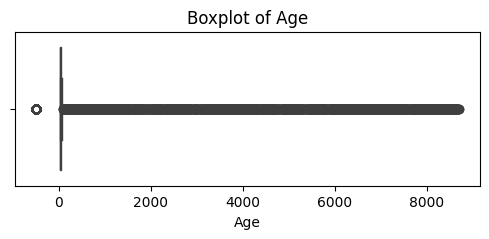

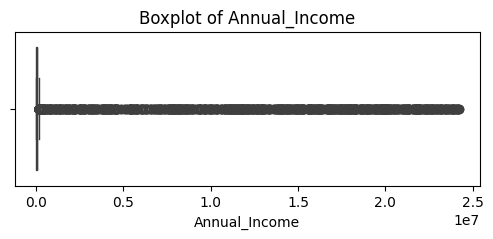

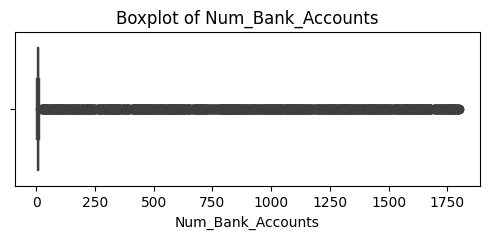

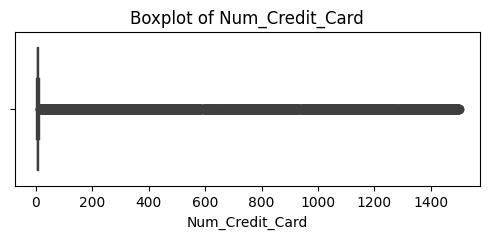

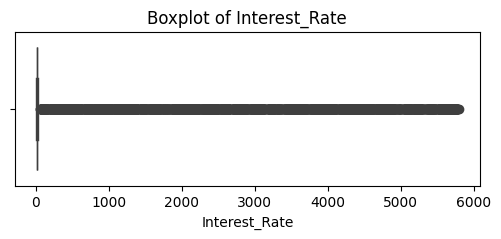

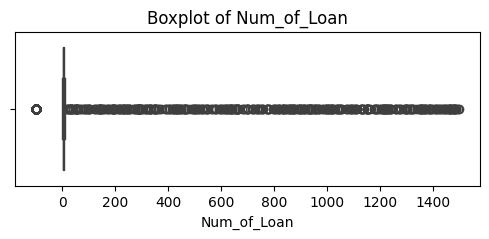

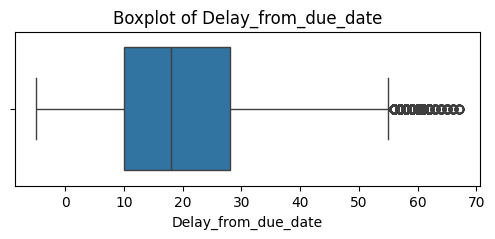

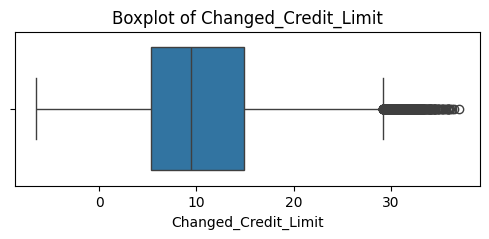

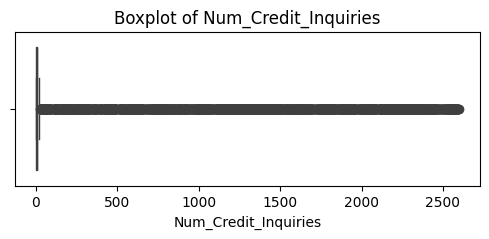

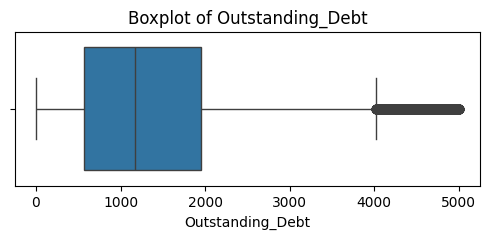

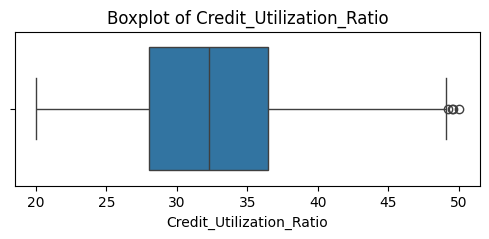

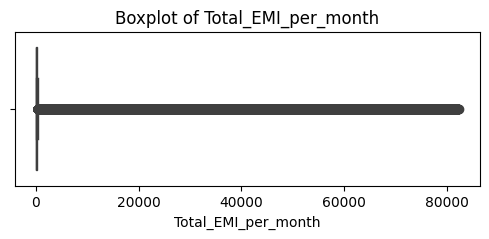

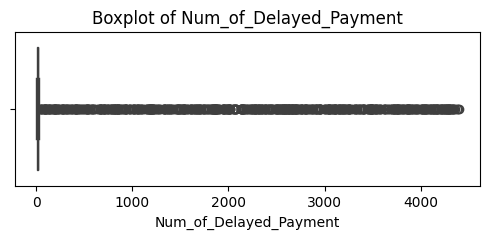

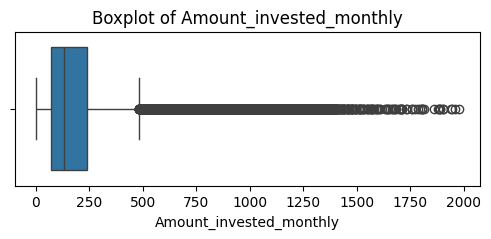

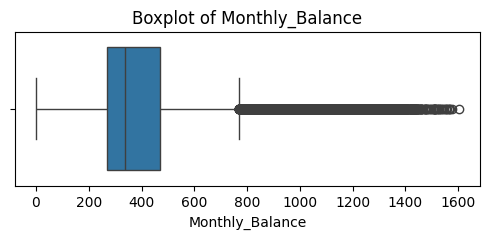

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df_train[col])
    plt.title(f"Boxplot of {col}")
    plt.show()



The boxplots revealed that several variables contain a large number of extreme values, causing severe distortion in their distributions.
We proceeded to remove the outliers present in our dataset. These extreme values could significantly distort the results of the analysis and negatively impact the performance of predictive models, as they introduced deviations that did not reflect the actual behavior of the majority of clients. By eliminating them, we aimed to obtain a more homogeneous and reliable dataset, allowing us to train more robust models with better generalization capabilities.

In [ ]:
def replace_outliers_with_NaN(df, columns, lower_percentile=5, upper_percentile=95):
    """
    Replace outliers with NaN using percentiles
    """
    df_clean = df.copy()
    reporte = {}

    for column in columns:
        # Calculate limits
        limite_inferior = df_clean[column].quantile(lower_percentile/100)
        limite_superior = df_clean[column].quantile(upper_percentile/100)

        # Identify outliers
        outliers_mask = (df_clean[column] < limite_inferior) | (df_clean[column] > limite_superior)
        outliers_indices = df_clean[outliers_mask].index.tolist()
        outliers_valores = df_clean.loc[outliers_indices, column].tolist()

        # Replace outliers with NaN
        n_outliers = outliers_mask.sum()
        df_clean.loc[outliers_mask, column] = np.nan

    return df_clean

# Use percentiles
df_percentiles = replace_outliers_with_NaN(df_train, numeric_cols)




We generated boxplots again to visualize the effect of the cleaning process on our variables.

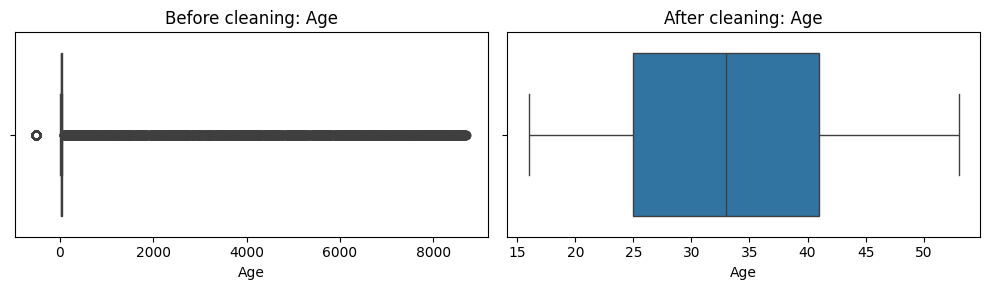

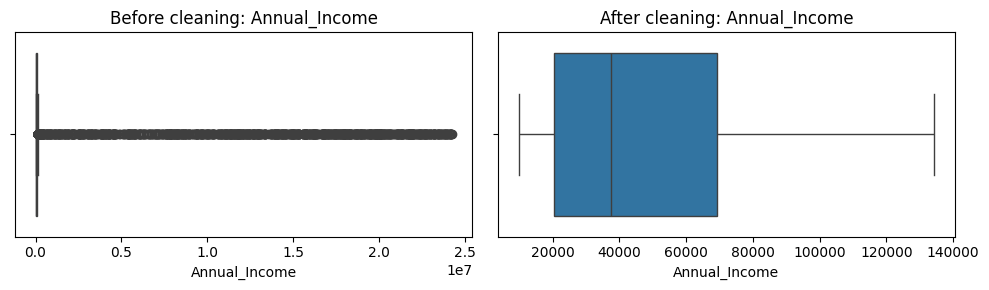

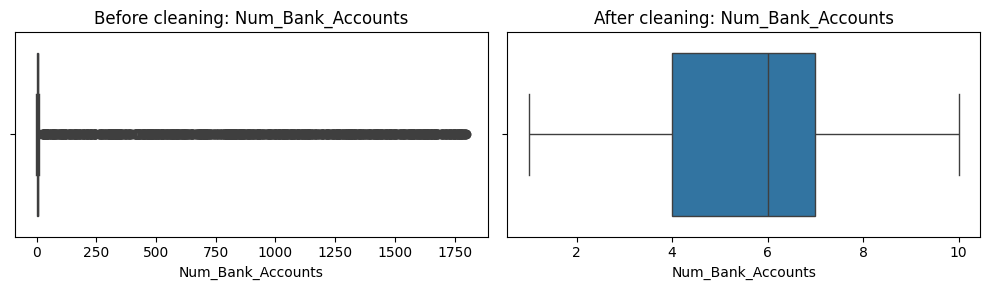

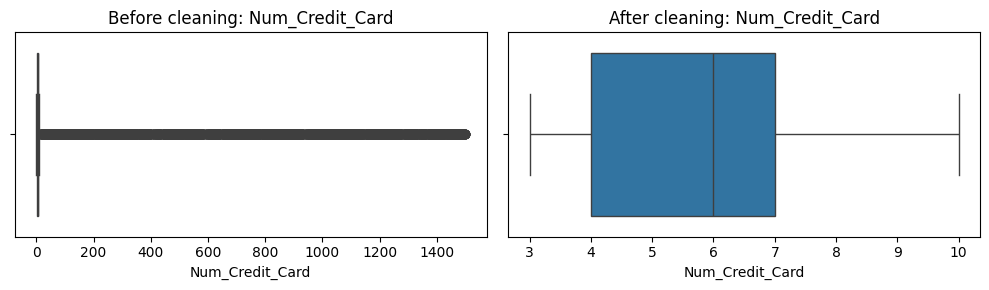

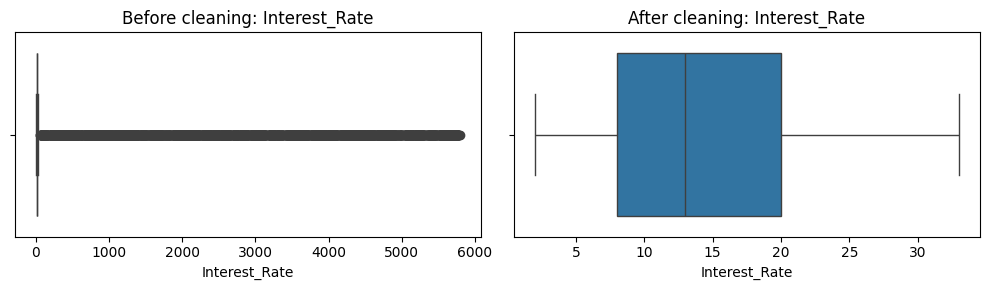

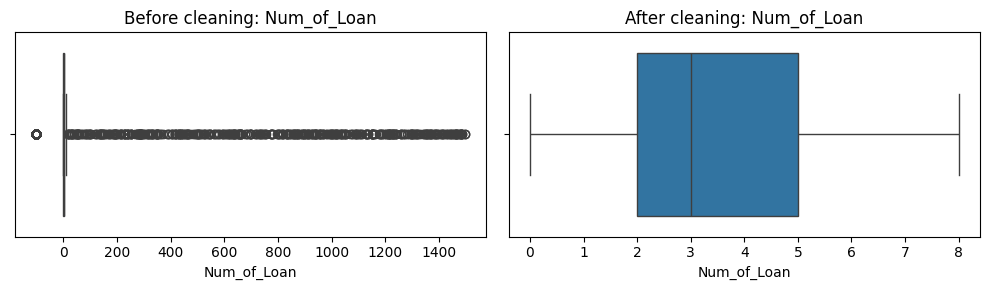

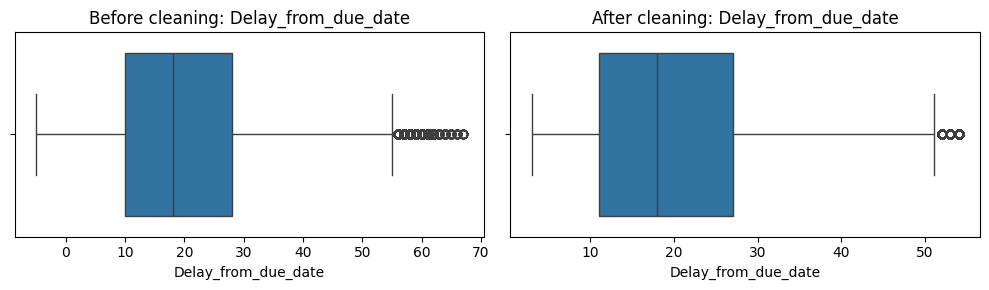

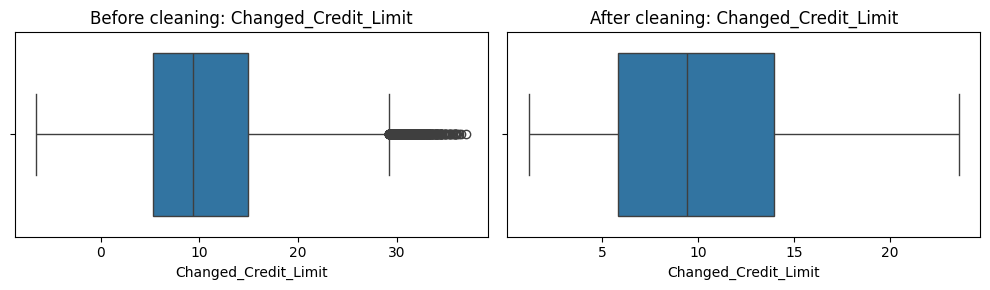

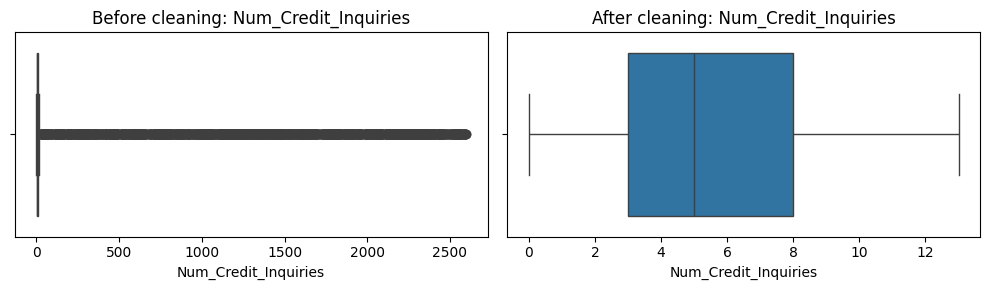

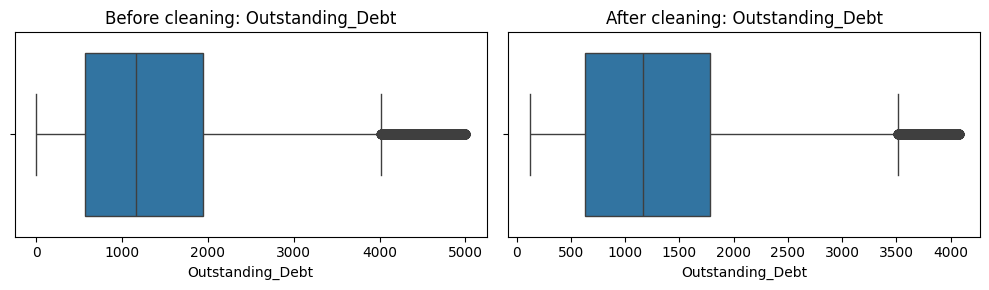

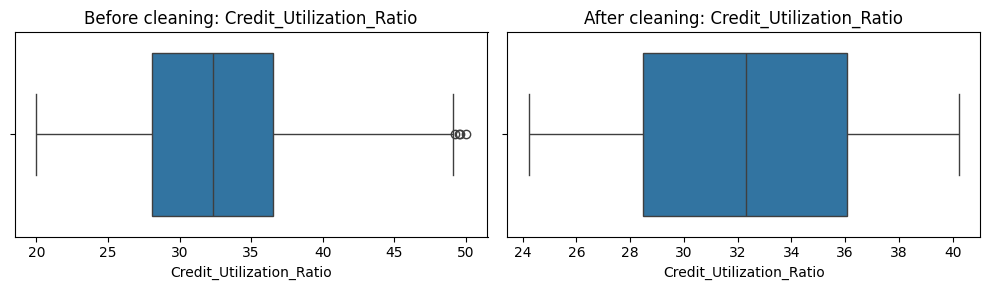

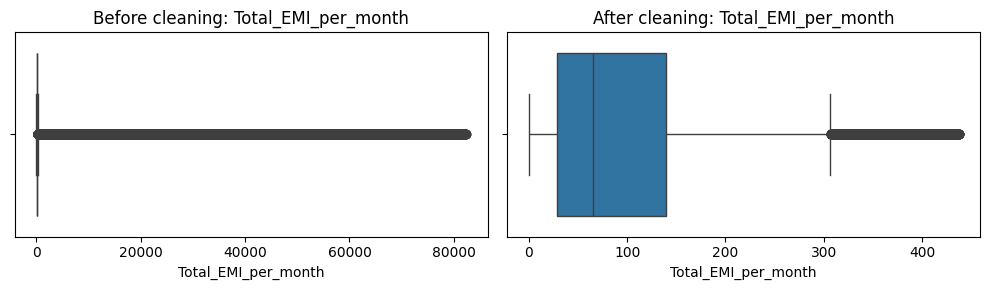

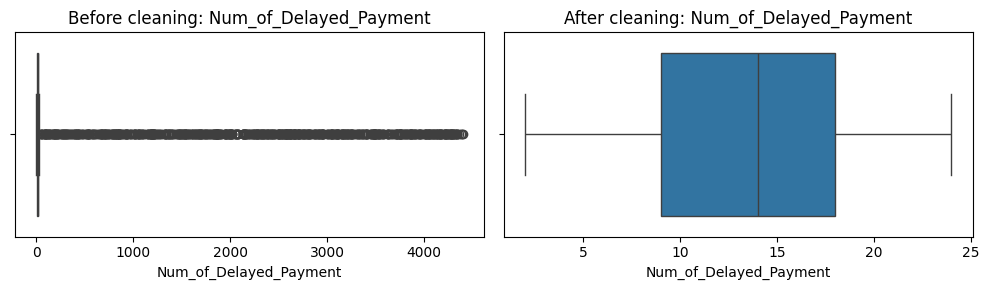

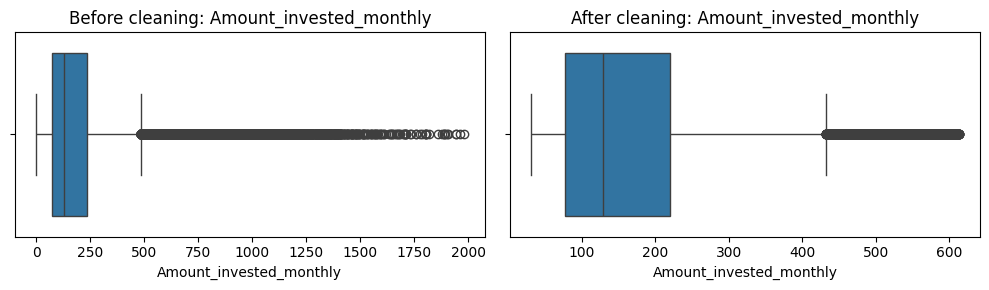

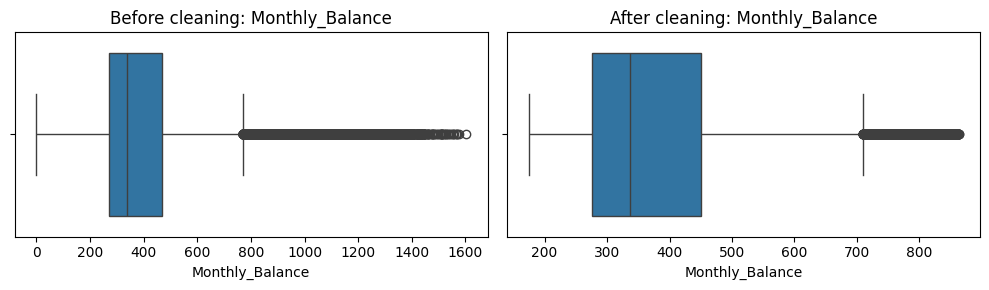

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(10, 3))

    # Avant nettoyage
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df_train[col])
    plt.title(f"Before cleaning: {col}")

    # Après nettoyage
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_percentiles[col])
    plt.title(f"After cleaning: {col}")

    plt.tight_layout()
    plt.show()

Once this process was completed, we began a new round of data cleaning, identifying the columns that still contained NaN values and determining which ones required further cleaning.

In [ ]:
Unknow = df_percentiles.isna().sum()[df_percentiles.isna().sum() > 0]
# Extract only the column names
columns_with_NaN = Unknow.index.tolist()
print(columns_with_NaN)

['Age', 'Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


In this dataset, most of the outliers and incorrectly entered data corresponded to a single data point for a client in a given month. However, we replaced these values with the data that the client most frequently had in other months, in an effort to preserve as much information as possible.

In [ ]:
from statistics import mode, StatisticsError

def fix_blocks(df):
    df = df.copy()
    n = len(df)
    for elem in df["Customer_ID"].unique():
        block=df[df["Customer_ID"] == elem]

        for col in columns_with_NaN:
            values = block[col].tolist()

            # If all values in the block are identical : nothing to change
            if len(set(values)) == 1:
                continue

            # If values differ : replace with the majority value
            try:
                majority_value = mode(values)
            except StatisticsError:
                # If there is a tie : use the first value in the block
                majority_value = values[0]

            # Replace all 8 rows with the majority value
            df.loc[(df["Customer_ID"] == elem) & (df[col].isna()), col] = majority_value
    return df


DatasetFinal = fix_blocks(df_percentiles)



In [ ]:
DatasetFinal.head(20)


,Customer_ID,Month,Age,Occupation,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0xd40,January,23.0,13,19114.12,3.0,4.0,3.0,4.0,3.0,...,4.0,0,809.98,26.822620,0,49.574949,80.415295,2,312.494089,Good
1,CUS_0xd40,February,23.0,13,19114.12,3.0,4.0,3.0,4.0,3.0,...,4.0,1,809.98,31.944960,0,49.574949,118.280222,3,284.629162,Good
2,CUS_0xd40,March,23.0,13,19114.12,3.0,4.0,3.0,4.0,3.0,...,4.0,1,809.98,28.609352,0,49.574949,81.699521,4,331.209863,Good
3,CUS_0xd40,April,23.0,13,19114.12,3.0,4.0,3.0,4.0,5.0,...,4.0,1,809.98,31.377862,0,49.574949,199.458074,5,223.451310,Good
4,CUS_0xd40,May,23.0,13,19114.12,3.0,4.0,3.0,4.0,6.0,...,4.0,1,809.98,24.797347,0,49.574949,41.420153,1,341.489231,Good
5,CUS_0xd40,June,23.0,13,19114.12,3.0,4.0,3.0,4.0,8.0,...,4.0,1,809.98,27.262259,0,49.574949,62.430172,5,340.479212,Good
6,CUS_0xd40,July,23.0,13,19114.12,3.0,4.0,3.0,4.0,3.0,...,4.0,1,809.98,26.822620,0,49.574949,178.344067,5,244.565317,Good
7,CUS_0xd40,August,23.0,13,19114.12,3.0,4.0,3.0,4.0,3.0,...,4.0,1,809.98,26.822620,0,49.574949,80.415295,1,358.124168,Bad
8,CUS_0x21b1,January,28.0,12,34847.84,2.0,4.0,6.0,1.0,3.0,...,2.0,1,605.03,24.464031,0,18.816215,104.291825,5,470.690627,Bad
9,CUS_0x21b1,February,28.0,14,34847.84,2.0,4.0,6.0,1.0,7.0,...,2.0,1,605.03,38.550848,0,18.816215,40.391238,0,484.591214,Good


Once the entire process was completed, we removed the rows for which it was impossible to recover information, as these corresponded to clients who had virtually no data. We retained only the clients for whom we had complete information in all relevant columns.

In [ ]:
DatasetFinal = DatasetFinal.dropna()


We examined correlations between numerical features because some models, such as Logistic Regression, perform better when the input variables are not strongly correlated.
Since we also want to compute the correlation between the features and the target variable (Credit_Score), we first convert its categories (Bad/Good/Standard) into numerical values.

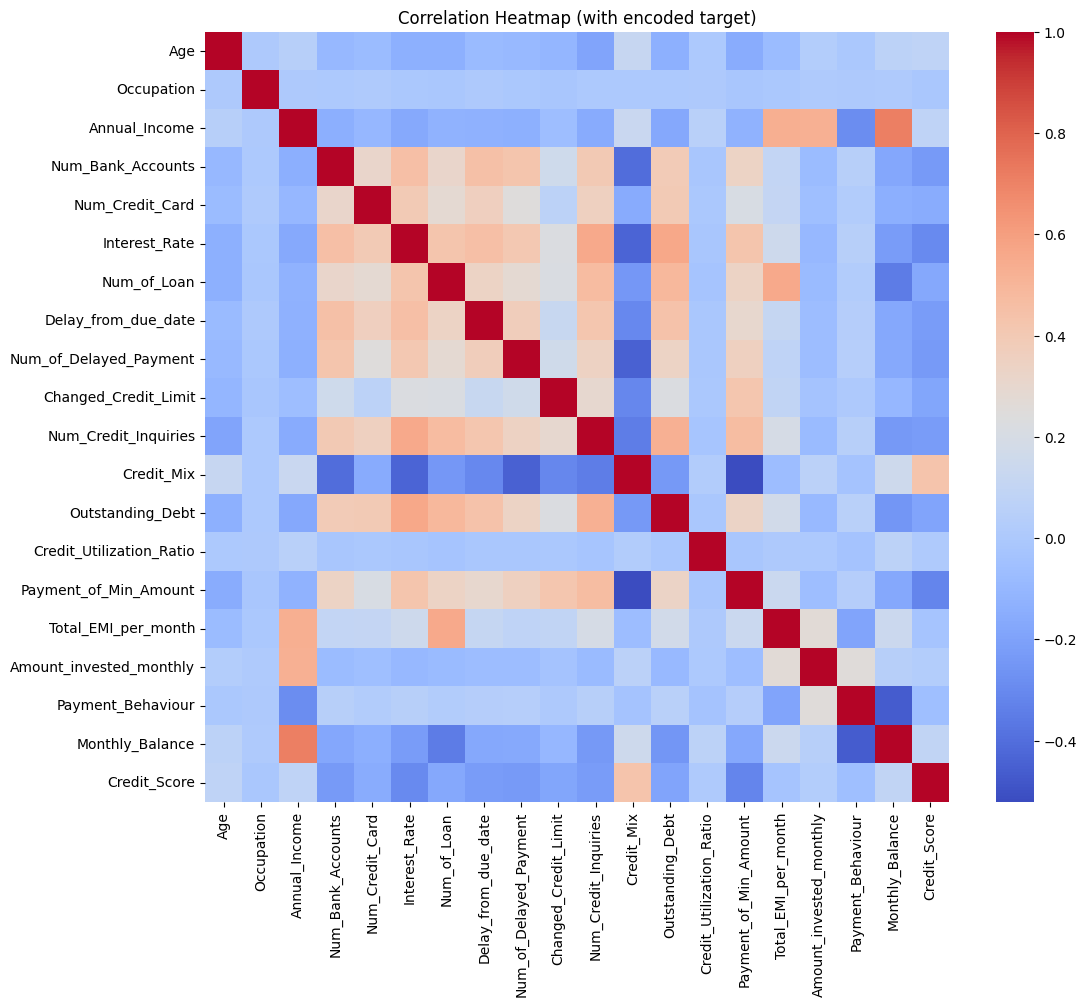

In [ ]:
# --- Encode Credit_Score for correlation ---
df_corr = DatasetFinal.copy()
le = LabelEncoder()
df_corr["Credit_Score"] = le.fit_transform(df_corr["Credit_Score"])

# --- Compute full correlation matrix ---
corr = df_corr.corr(numeric_only=True)

# --- Heatmap ---
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (with encoded target)")
plt.show()




Our threshold for detecting strong correlations between features was set to 0.6. Only one pair of features (Annual_Income and Monthly_Balance) exceeded this threshold. Since their correlation coefficient is not extremely high (approximately 0.7), we do not need to remove either variable.

In [ ]:
# --- Find strongly correlated pairs ---
corr_matrix = corr.abs()

pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

strong_pairs = pairs[pairs[0] > 0.6].sort_values(0, ascending=False)
print("Strongly correlated pairs (> 0.6):")
print(strong_pairs)

Strongly correlated pairs (> 0.6):
          level_0          level_1         0
52  Annual_Income  Monthly_Balance  0.711801



To identify which features are most related to the target variable (Credit_Score), we compute the correlation of every numerical feature with the target and sort the results in decreasing order.



In [ ]:
# --- Correlation with target only ---
target_corr = corr["Credit_Score"].abs().sort_values(ascending=False)
print("\nCorrelation with target (Credit_Score):")
print(target_corr)


Correlation with target (Credit_Score):
Credit_Score                1.000000
Credit_Mix                  0.431489
Payment_of_Min_Amount       0.318304
Interest_Rate               0.298296
Num_of_Delayed_Payment      0.235209
Num_Bank_Accounts           0.231570
Num_Credit_Inquiries        0.229288
Delay_from_due_date         0.224435
Outstanding_Debt            0.190938
Changed_Credit_Limit        0.187033
Num_of_Loan                 0.172581
Num_Credit_Card             0.157913
Monthly_Balance             0.095690
Age                         0.083073
Annual_Income               0.082400
Payment_Behaviour           0.063081
Amount_invested_monthly     0.030155
Total_EMI_per_month         0.027935
Occupation                  0.012988
Credit_Utilization_Ratio    0.010455
Name: Credit_Score, dtype: float64



Overall, no feature exhibits a very strong linear correlation with the target, meaning that the credit score is influenced by several moderate factors rather than one dominant variable. Since simple correlations capture only linear effects, they may fail to detect meaningful non-linear patterns or combined effects.
To overcome this limitation, we performed feature engineering and created new variables that better reflect realistic financial concepts.



Now we are going to create new variables from the existing ones, and we are going to carry out a study to determine which variables are the most representative for predicting our target variable.

In [ ]:
# 1. Total number of accounts (Bank + Credit Card)
DatasetFinal['Total_Num_Accounts'] = DatasetFinal['Num_Bank_Accounts'] + DatasetFinal['Num_Credit_Card']
# 2. Debt per account
DatasetFinal['Debt_Per_Account'] = DatasetFinal['Outstanding_Debt'] / DatasetFinal['Total_Num_Accounts']
# 3. Calculate the ratio of outstanding debt to annual income
DatasetFinal['Debt_to_Income_Ratio'] = DatasetFinal['Outstanding_Debt'] / DatasetFinal['Annual_Income']
# 4. Calculate the total number of delayed payments per account
DatasetFinal['Delayed_Payments_Per_Account'] = DatasetFinal['Num_of_Delayed_Payment'] / DatasetFinal['Total_Num_Accounts']

To evaluate whether a numerical variable helps separate Good and Bad customers, we compare the two boxplots (one per class). A variable is more discriminative when:
- the medians are far apart,
- the boxes do not overlap much,
- the whiskers do not overlap.

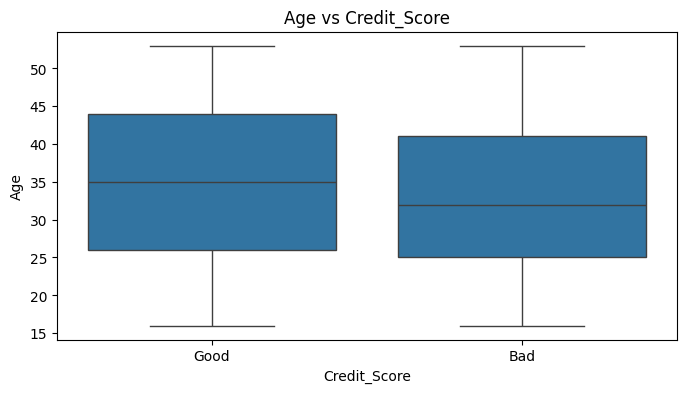

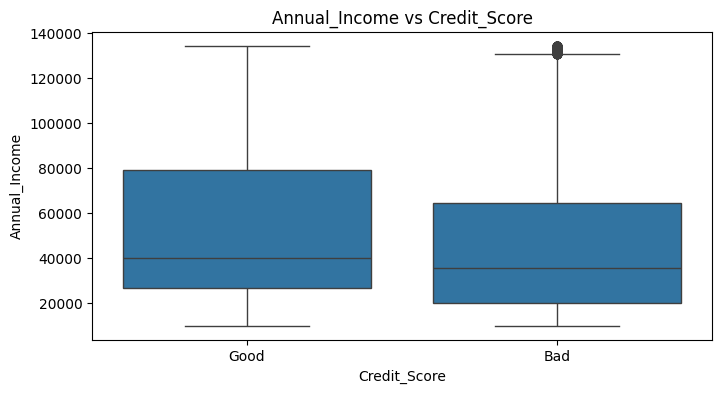

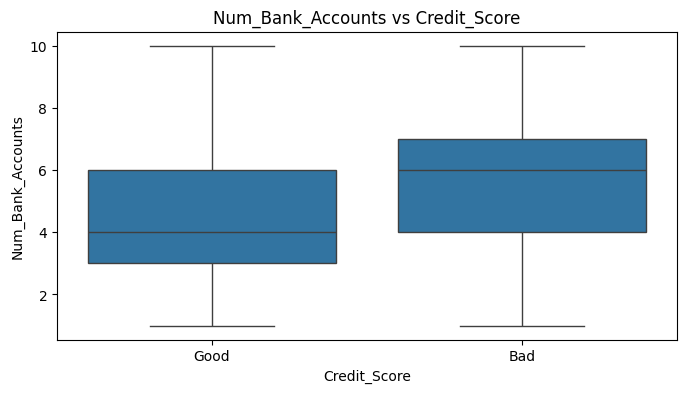

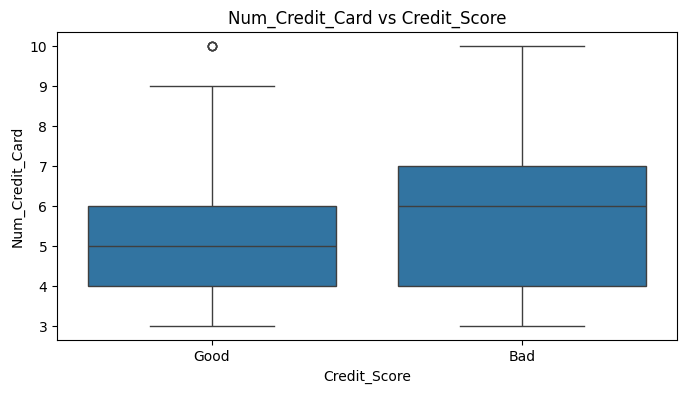

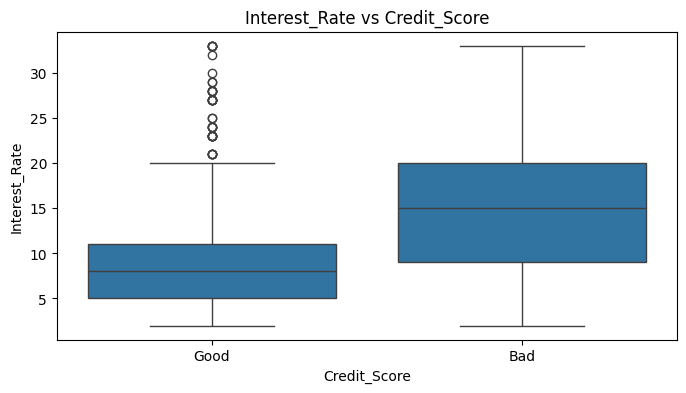

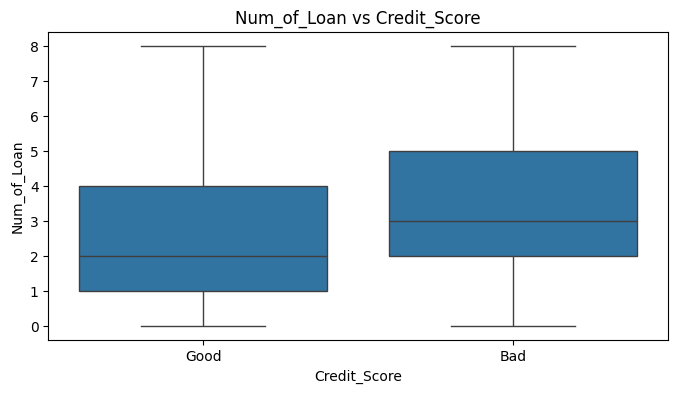

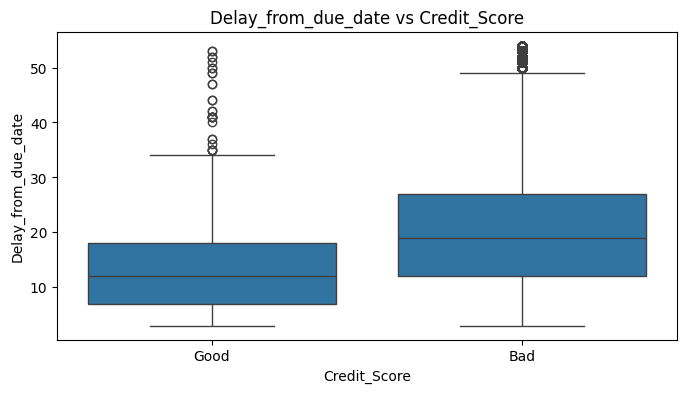

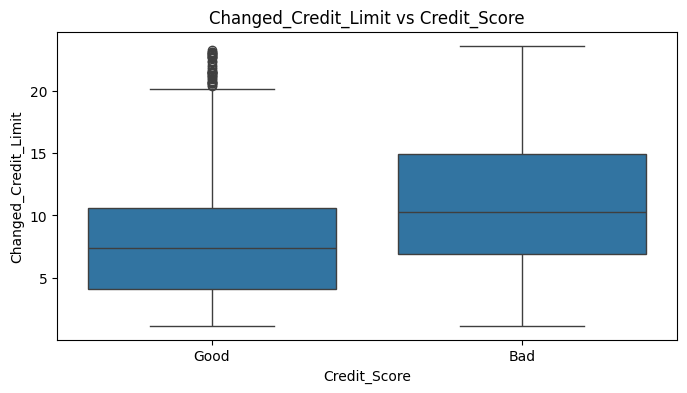

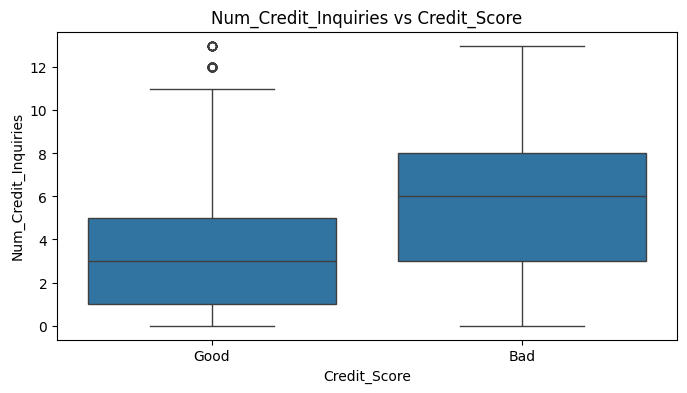

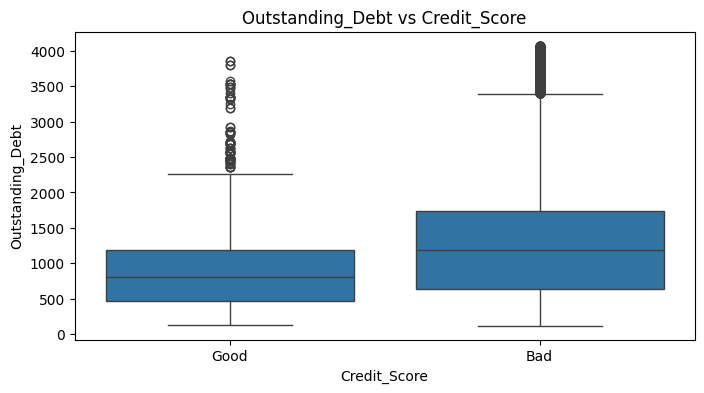

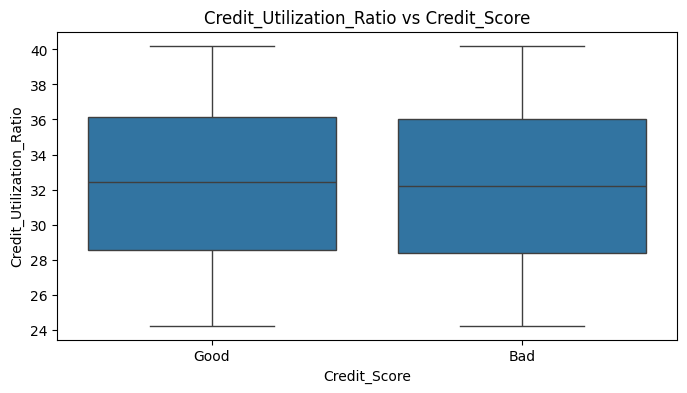

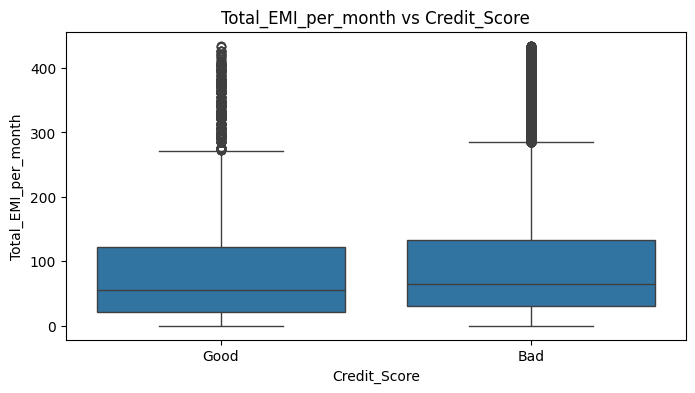

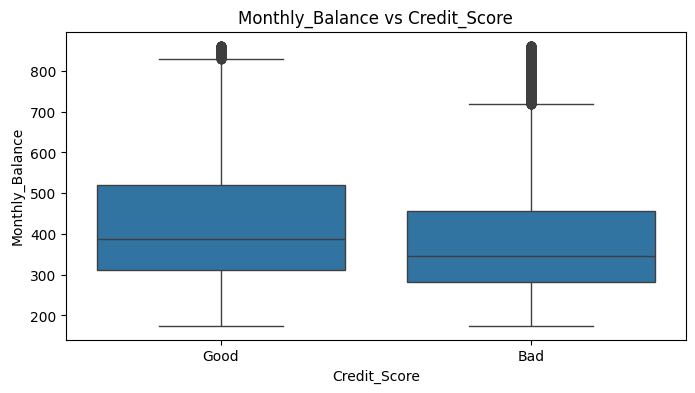

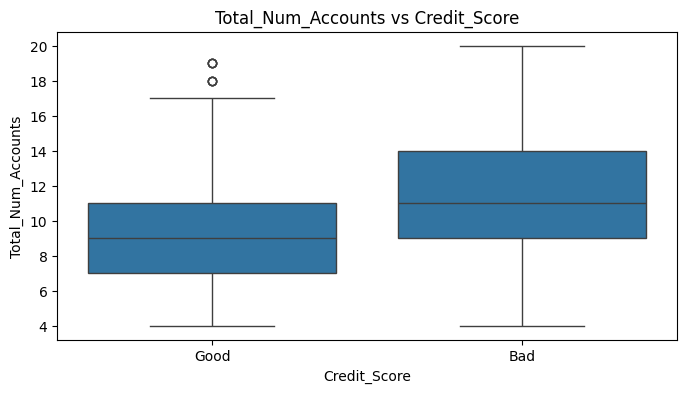

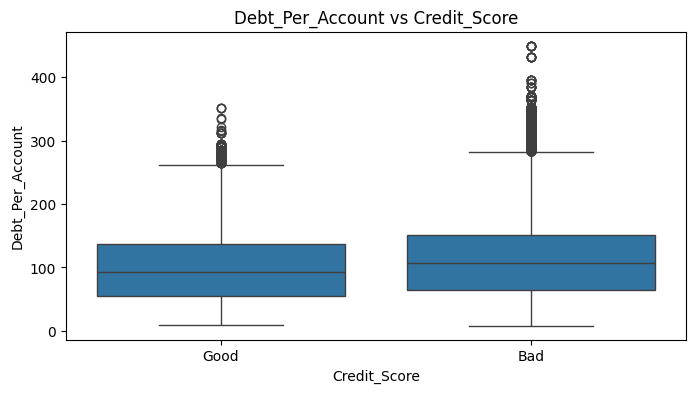

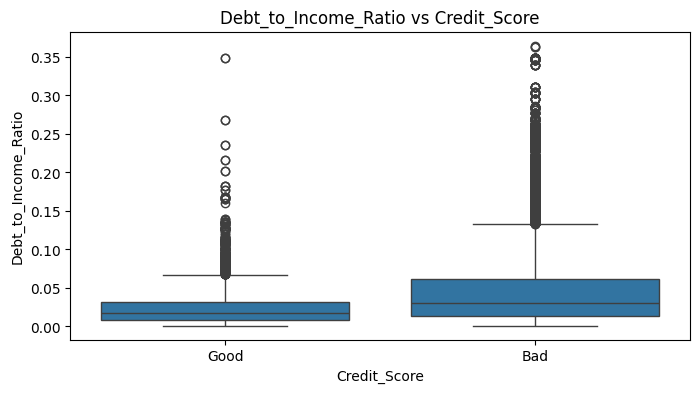

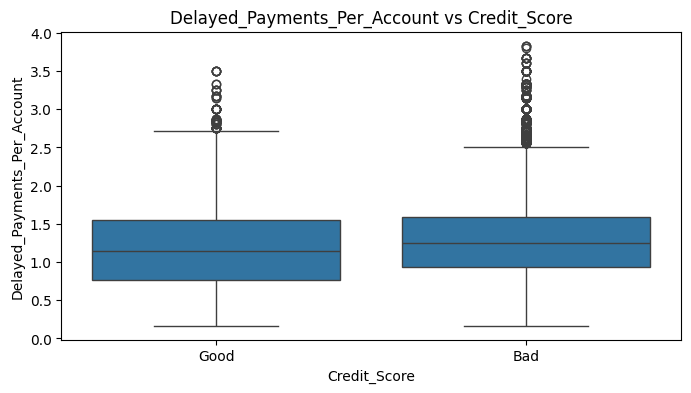

In [ ]:
numeric_cols = ['Age','Annual_Income',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
       'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month','Monthly_Balance',
       # New features
       'Total_Num_Accounts',
       'Debt_Per_Account',
       'Debt_to_Income_Ratio',
       'Delayed_Payments_Per_Account'
]


# --- Boxplots : Credit_Score vs each numerical variable ---
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=DatasetFinal, x='Credit_Score', y=col)
    plt.title(f"{col} vs Credit_Score")
    plt.show()



We observe substantial overlap between the Good and Bad categories for several numerical variables, including Age, Annual_Income, Num_of_Loan, Credit_Utilization_Ratio, Total_EMI_per_month, and Amount_invested_monthly. Boxplots only apply to numerical features and capture simple, linear differences between groups, providing mainly qualitative insight.
To obtain a more complete and quantitative assessment, we compute Mutual Information (MI), which can detect nonlinear relationships and also works with categorical variables.

Now we are going to proceed to graphically examine which of the variables we had before, along with the new ones we have created, are the most representative for our target variable.

In [ ]:
from sklearn.feature_selection import mutual_info_classif

y = DatasetFinal['Credit_Score']
X = DatasetFinal.drop(columns=['Credit_Score','Customer_ID','Month',])

mi_scores = mutual_info_classif(X, y)
sorted_mi_scores = sorted(zip(X.columns, mi_scores), key=lambda x: x[1], reverse=True)
sorted_columns = [x[0] for x in sorted_mi_scores]
sorted_scores = [x[1] for x in sorted_mi_scores]

for i, score in enumerate(mi_scores):
    print(f"Feature '{X.columns[i]}': Mutual Information Score = {score}")



Feature 'Age': Mutual Information Score = 0.01041733127149369
Feature 'Occupation': Mutual Information Score = 0.002623179135071707
Feature 'Annual_Income': Mutual Information Score = 0.24493549168378737
Feature 'Num_Bank_Accounts': Mutual Information Score = 0.03627752130046957
Feature 'Num_Credit_Card': Mutual Information Score = 0.018337871275541984
Feature 'Interest_Rate': Mutual Information Score = 0.06440240394295693
Feature 'Num_of_Loan': Mutual Information Score = 0.024425364726355925
Feature 'Delay_from_due_date': Mutual Information Score = 0.037246460126294734
Feature 'Num_of_Delayed_Payment': Mutual Information Score = 0.03227234461763162
Feature 'Changed_Credit_Limit': Mutual Information Score = 0.06179439392386654
Feature 'Num_Credit_Inquiries': Mutual Information Score = 0.03216666276469793
Feature 'Credit_Mix': Mutual Information Score = 0.0708158252181399
Feature 'Outstanding_Debt': Mutual Information Score = 0.24237796628255293
Feature 'Credit_Utilization_Ratio': Mutua

Once we have examined the graph, we decide that the variables with a value below an 2% threshold will be removed from our dataset, so that we can work only with the most representative variables in our dataset.

In [ ]:
print(sorted_columns[17:])


['Num_Credit_Card', 'Monthly_Balance', 'Age', 'Credit_Utilization_Ratio', 'Payment_Behaviour', 'Occupation']


In [ ]:
columns_to_drop = sorted_columns[17:]
DatasetFinal.drop(columns=columns_to_drop, inplace=True)


Now we look at the correlations between the variables, to discard highly correlated variables:

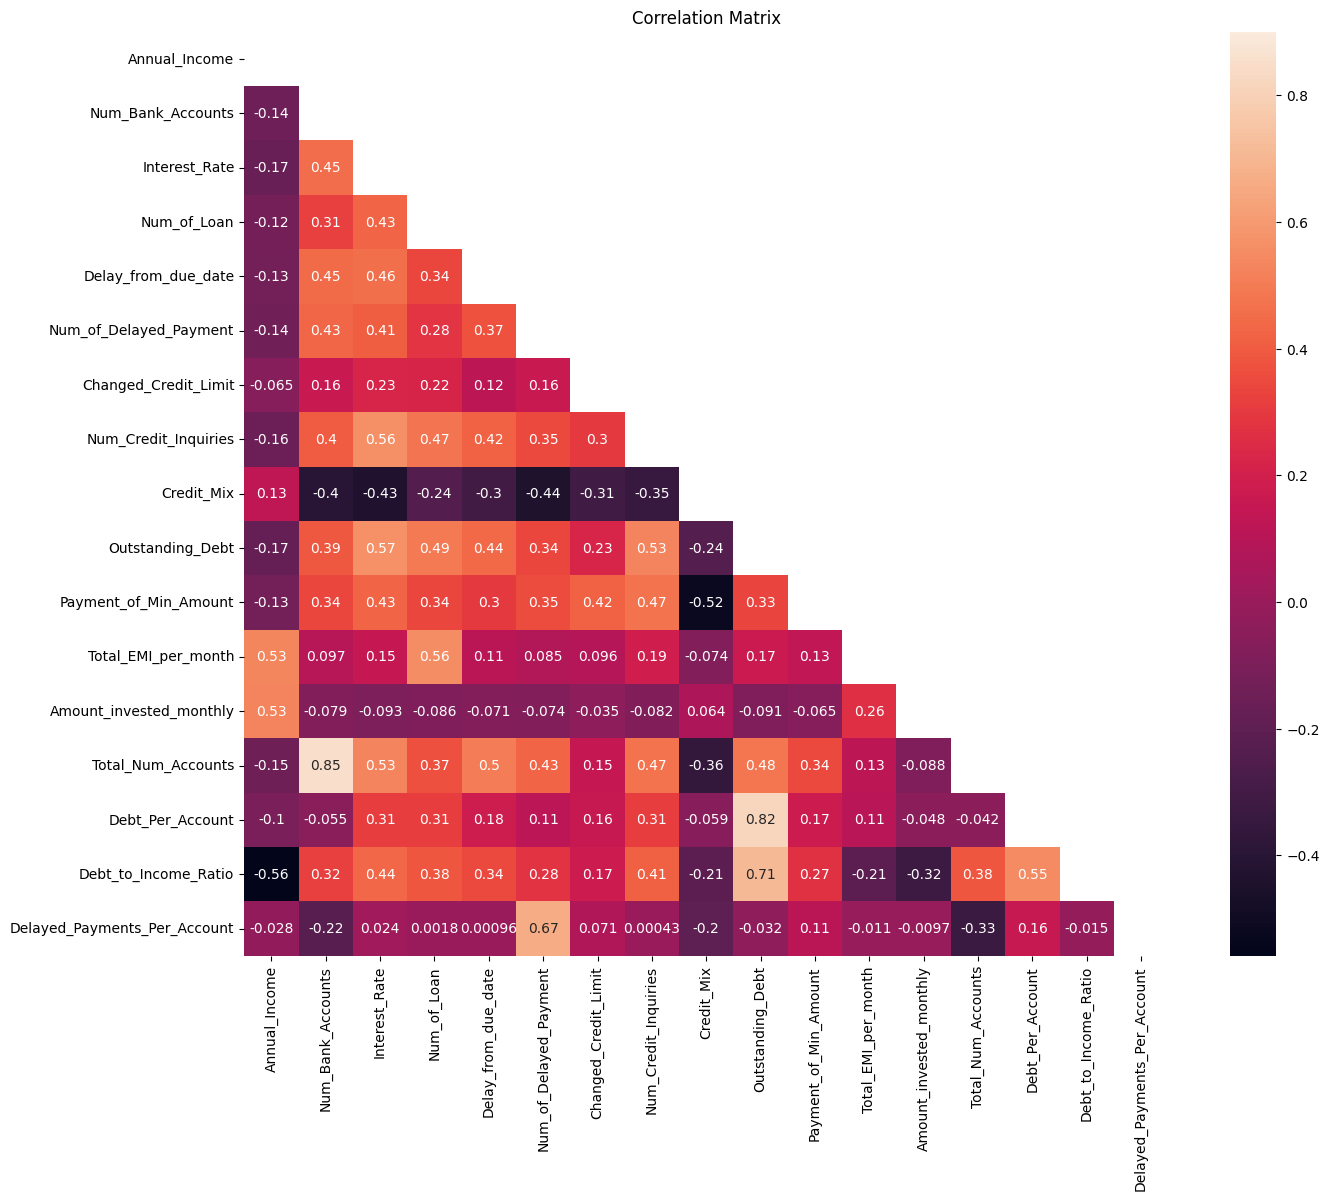

In [ ]:
# Calculate Correlation Matrix

corr = DatasetFinal.select_dtypes(include=['float64', 'int64']).corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr, mask=mask, vmax=0.9, square=True, annot=True)
plt.title('Correlation Matrix')
plt.show()

We use a threshold of 0.7 and discard one variable from each pair whose correlation coefficient exceeds this threshold.

In [ ]:
corr_threshold = 0.7

# Compute correlation matrix
corr_matrix = DatasetFinal.select_dtypes(include=['float64', 'int64']).corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation above threshold
to_drop = [column for column in upper.columns if any(upper[column] > corr_threshold)]

print("Variables to drop due to high correlation:")
print(to_drop)



Variables to drop due to high correlation:
['Total_Num_Accounts', 'Debt_Per_Account', 'Debt_to_Income_Ratio']


Once the entire process was completed, we saved our new, cleaned dataset, which would be used to train our models to predict which clients were good and which were bad.

In [ ]:
DatasetFinal.to_csv("Final_Dataset4.csv", index=False)

We load the cleaned dataset and separate the target variable from the other explanatory variables.

In [ ]:
df=pd.read_csv("Final_Dataset4.csv")
df = df.dropna()
# We relabel the target variable
encoder = OneHotEncoder(sparse_output=False, drop='first')
y = encoder.fit_transform(df[["Credit_Score"]])
y = y.flatten()
X_df = df.copy()
# We remove variables that we will not use
X_df.drop(columns = ["Credit_Score","Customer_ID","Month"], inplace = True)

We standardize the data.

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X_df)

### Split the data into a training set and a test set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.20, random_state=77
)

We now see that there is an imbalance in the proportion of elements in each class:

In [ ]:
v_u, num = np.unique(y_train, return_counts=True)

for i, j in zip(v_u, num):
    print(f"Clase {i}: {j} elements")

Clase 0.0: 36446 elements
Clase 1.0: 5577 elements


We will correct it using the SMOTE function :

In [ ]:
# Only apply this chunk if the SMOTE function is not working:
# pip install imbalanced-learn

In [ ]:
warnings.filterwarnings("ignore", category=UserWarning)
smote = SMOTE(random_state=77)
train_xs, train_ys  = smote.fit_resample(X_train, y_train)
test_xs, test_ys  = smote.fit_resample(X_test, y_test)

v_u, num = np.unique(train_ys, return_counts=True)

for i, j in zip(v_u, num):
    print(f"Clase {i}: {j} elements")

Clase 0.0: 36446 elements
Clase 1.0: 36446 elements


## Select Model

To select the best model for our Credit Score prediction project, we will begin by training the most promising model types identified in our research, comparing them with different combinations of their hyperparameters.

### Models

#### Logistic Regression Multinomial

A linear model that uses a logistic function to predict class probabilities. It is fast to train and serves as an excellent baseline model.

#### Bagging Classifier

An ensemble method that trains multiple base classifiers on random data subsets and aggregates their predictions via majority voting. It effectively reduces variance and overfitting, making it a robust and stable choice for classification problems.

#### Random Forest

An ensemble method that builds multiple decision trees and combines their predictions. It reduces overfitting and it is ideal for credit risk data.

#### Gradient Boosting

Advanced ensemble technique that builds trees sequentially to correct previous errors. It consistently excels in financial forecasting tasks.

### Performance Metrics

#### Training Time

Total time required to train the model on the training dataset:

$$\mathrm{TrTime} = t_{\mathrm{end}} - t_{\mathrm{start}} \quad \text{(seconds)}$$

#### Accuracy

Measures the overall correctness of the model by calculating the ratio of correct predictions to total predictions:

$$ Accuracy
= \frac{\mathrm{TP} + \mathrm{TN}}{\mathrm{P} + \mathrm {N}}
= \frac{\mathrm{TP} + \mathrm{TN}}
    {\mathrm{TP} + \mathrm{TN} + \mathrm {FP} +\mathrm {FN}}
$$

#### Precision

Measures the quality of positive predictions by calculating the percentage of positive predictions that were actually correct:

$$\mathrm{Precision} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FP}}$$

#### Recall

Measures the model's ability to detect positive instances by calculating the percentage of actual positives that were correctly identified:

$$\mathrm{Recall} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FN}}$$

#### F1-Score

Harmonic mean of precision and recall:

$$\mathrm{F1} = 2 \times \frac{\mathrm{Precision} \times \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}$$

#### Specificity

Measures the model's ability to correctly identify negative cases by calculating the proportion of actual negative instances that are correctly predicted as negative:

$$\mathrm{Specificity} = \frac{\mathrm{TN}}{\mathrm{TN} + \mathrm{FP}}$$

#### False Positive Rate

Measures the proportion of actual negative instances that are incorrectly classified as positive:

$$\mathrm{FPR} = \frac{\mathrm{FP}}{\mathrm{FP} + \mathrm{TN}}$$

#### ROC-AUC

Measures the model's ability to distinguish between classes across all classification thresholds:

$$\mathrm{TPR} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FN}}, \quad \mathrm{FPR} = \frac{\mathrm{FP}}{\mathrm{FP} + \mathrm{TN}}
\mathrm{AUC} = \int_{0}^{1} \mathrm{TPR} , d(\mathrm{FPR})$$

#### Prediction Time

Time required to make predictions on new data after training:

$$\mathrm{PrTime} = t_{\mathrm{pr_end}} - t_{\mathrm{pr_start}} \quad \text{(seconds)}$$

For our model evaluation, the key metric of focus is the F1-score pertaining to the 'good clients' class. This emphasis aligns with the primary business goal of accurately predicting trustworthy clients.

### Models and Hyperparameters

First, we will define two lists, one to store the models and another to store the hyperparameters to be considered for each model:

In [ ]:
from sklearn.pipeline import Pipeline
# Define the pipelines for each model
pipelines = {
    'logistic': Pipeline([
        ('model', LogisticRegression(random_state=28, max_iter=1000, class_weight='balanced'))
    ]),

    'random_forest': Pipeline([
        ('model', RandomForestClassifier(random_state=28, class_weight='balanced'))
    ]),

    'bagging': Pipeline([
        ('model', BaggingClassifier(random_state=28))
    ]),

    'gradient_boost': Pipeline([
        ('model', GradientBoostingClassifier(random_state=28))
    ])
}

# Define possible hyperparameters
param_grids = {
    'logistic': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['liblinear', 'saga'],
    },

    'random_forest': {
        'model__n_estimators': [50, 100, 200],
        'model__max_features': ['sqrt', 'log2'],
        'model__class_weight': ['balanced', 'balanced_subsample', None],
        'model__bootstrap': [True, False]
    },

    'bagging': {
        'model__n_estimators': [50, 100, 200],
        'model__max_samples': [0.5, 0.7, 1.0],
        'model__max_features': [0.5, 0.7, 1.0],
        'model__bootstrap': [True, False]
    },

    'gradient_boost': {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 4, 5],
        'model__subsample': [0.8, 0.9, 1.0]
    }
}

### Grid Search

Then, using grid search, we will proceed to search for each model which combination of hyperparameters yields the highest F1-score:

In [ ]:
from sklearn.model_selection import GridSearchCV
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(
    sampling_strategy='auto',
    random_state=42,
    replacement=False
)

Xw_train, yw_train = rus.fit_resample(X_train, y_train)

def model_f1(model_name, pipeline, param_grid, X_train, y_train, cv=5, n_iter=30):
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1,
        verbose=1 # change to 1, otherwise too long
    )
    search.fit(X_train, y_train)

    # Results
    print(model_name)
    print(f"Best parameters: {search.best_params_}")
    print(f"CV score: {search.best_score_:.4f}")
    return [model_name, search.best_params_,search.best_score_]

best_models = []

# Apply Grid for each model
for name in pipelines.keys():
    best_model = model_f1(
        model_name=name,
        pipeline=pipelines[name],
        param_grid=param_grids[name],
        X_train=Xw_train,
        y_train=yw_train,
        cv=5,
        n_iter=20)
    best_models.append(best_model)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic
Best parameters: {'model__C': 10, 'model__solver': 'liblinear'}
CV score: 0.7799
Fitting 5 folds for each of 36 candidates, totalling 180 fits
random_forest
Best parameters: {'model__bootstrap': False, 'model__class_weight': None, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
CV score: 0.8570
Fitting 5 folds for each of 54 candidates, totalling 270 fits
bagging
Best parameters: {'model__bootstrap': False, 'model__max_features': 0.5, 'model__max_samples': 1.0, 'model__n_estimators': 200}
CV score: 0.8760
Fitting 5 folds for each of 81 candidates, totalling 405 fits
gradient_boost
Best parameters: {'model__learning_rate': 0.2, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
CV score: 0.8459


### Evaluation Best Models

Once we have obtained the best hyperparameters for each model, we will proceed to evaluate and compare them:

#### Definition of necessary functions

In [ ]:
from sklearn.metrics import (f1_score, precision_score, recall_score,
                           accuracy_score, roc_auc_score, classification_report,
                           confusion_matrix)
def evaluate_model(model, model_name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    f1_class1 = f1_score(y_test, y_pred, pos_label=1)
    precision_class1 = precision_score(y_test, y_pred, pos_label=1)
    recall_class1 = recall_score(y_test, y_pred, pos_label=1)
    accuracy = accuracy_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    print(f"\n{'='*60}")
    print(f"EVALUATION: {model_name.upper()}")
    print(f"{'='*60}")

    print(f"METRICS FOR GOOD CLIENTS:")
    print(f"  F1-Score:     {f1_class1:.4f}")
    print(f"  Precision:    {precision_class1:.4f}")
    print(f"  Recall:       {recall_class1:.4f}")
    print(f"  Accuracy:     {accuracy:.4f}")
    if auc_roc:
        print(f"  AUC-ROC:      {auc_roc:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Bad', 'Good']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion matrix:")
    print(cm)
    return {
        'model_name': model_name,
        'f1_class1': f1_class1,
        'precision_class1': precision_class1,
        'recall_class1': recall_class1,
        'accuracy': accuracy,
        'auc_roc': auc_roc,
        'confusion_matrix': cm
    }

def reconstruct_and_evaluate_models(best_models_list, X_train, y_train, X_test, y_test):
    trained_models = {}
    evaluation_results = []
    base_pipelines = {
        'logistic': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(random_state=28, max_iter=1000, class_weight='balanced'))
        ]),

        'random_forest': Pipeline([
            ('model', RandomForestClassifier(random_state=28, class_weight='balanced'))
        ]),

        'bagging': Pipeline([
            ('model', BaggingClassifier(random_state=28))
        ]),

        'gradient_boost': Pipeline([
            ('model', GradientBoostingClassifier(random_state=28))
        ])
    }

    for model_info in best_models_list:
        model_name = model_info[0]
        best_params = model_info[1]
        cv_score = model_info[2]

        print(f"\n▶ Processing {model_name.upper()}:")
        pipeline = base_pipelines[model_name]
        pipeline.set_params(**best_params)
        print(f"  Training model...")
        pipeline.fit(X_train, y_train)
        trained_models[model_name] = pipeline
        results = evaluate_model(pipeline, model_name, X_test, y_test)
        evaluation_results.append(results)

    return trained_models, evaluation_results

#### Model Comparison

In [ ]:
trained_models_dict, evaluation_results_list = reconstruct_and_evaluate_models(
    best_models,
    train_xs,
    train_ys,
    test_xs,
    test_ys
)


▶ Processing LOGISTIC:
  Training model...

EVALUATION: LOGISTIC
METRICS FOR GOOD CLIENTS:
  F1-Score:     0.7835
  Precision:    0.7871
  Recall:       0.7800
  Accuracy:     0.7845
  AUC-ROC:      0.8470

Classification Report:
              precision    recall  f1-score   support

         Bad       0.78      0.79      0.79      9100
        Good       0.79      0.78      0.78      9100

    accuracy                           0.78     18200
   macro avg       0.78      0.78      0.78     18200
weighted avg       0.78      0.78      0.78     18200

Confusion matrix:
[[7180 1920]
 [2002 7098]]

▶ Processing RANDOM_FOREST:
  Training model...

EVALUATION: RANDOM_FOREST
METRICS FOR GOOD CLIENTS:
  F1-Score:     0.9141
  Precision:    0.9544
  Recall:       0.8770
  Accuracy:     0.9176
  AUC-ROC:      0.9707

Classification Report:
              precision    recall  f1-score   support

         Bad       0.89      0.96      0.92      9100
        Good       0.95      0.88      0.91    

## Fit the Model and Results

The Bagging Classifier performed best, so we'll move forward with it. Let's look at the results:

In [ ]:
ModelBag = trained_models_dict["bagging"]
st_time = time.time()
ModelBag.fit(train_xs, train_ys)
tr_time = round(time.time() - st_time,4)
TR_time = []
TR_time.append(tr_time)

### Bootstrapping

Now, to ensure accurate model results, we'll apply a bootstrap method to the test dataset. The goal is to obtain confidence intervals for the model's performance metrics.

#### Definition of necessary functions

Our first step is to define the functions for bootstrapping, calculating metrics, determining confidence intervals, and presenting the results:

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, confusion_matrix

def bootstrap_test(X_test, y_test, n_samples=1000):
    n = len(X_test)
    bootstrap_samples_X = []
    bootstrap_samples_y = []

    for i in range(n_samples):
        ind = resample(np.arange(n))
        X_sample = X_test[ind,]
        y_sample = y_test[ind]

        bootstrap_samples_X.append(X_sample)
        bootstrap_samples_y.append(y_sample)

    return bootstrap_samples_X,bootstrap_samples_y

# Specificity
def cal_specificity(y_test, y_pred):
        cm = confusion_matrix(y_test, y_pred)
        n_classes = cm.shape[0]
        specificities = []
        supports = []

        for i in range(n_classes):
            # True negatives for class i: all instances that are not i and were not predicted as i
            tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
            # False positives for class i: instances that are not i but were predicted as i
            fp = np.sum(cm[:, i]) - cm[i, i]
            # Support for class i (actual instances of class i)
            support = np.sum(cm[i, :])

            if tn + fp == 0:
                specificity_i = 0
            else:
                specificity_i = tn / (tn + fp)

            specificities.append(specificity_i)
            supports.append(support)

        return specificities[1]

# False Positive Rate
def cal_fpr(y_test, y_pred):
        cm = confusion_matrix(y_test, y_pred)
        n_classes = cm.shape[0]
        fprs = []
        supports = []

        for i in range(n_classes):
            tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
            fp = np.sum(cm[:, i]) - cm[i, i]
            support = np.sum(cm[i, :])

            if fp + tn == 0:
                fpr_i = 0
            else:
                fpr_i = fp / (fp + tn)

            fprs.append(fpr_i)
            supports.append(support)

        return fprs[1]

# All metrics
def Eval_models(models_dict, bootstrap_X, bootstrap_y, Trtime):

    results = {}

    for model_name, model in models_dict.items():
        print(f"Evaluating {model_name}...")
        metrics = {
            'Training_time': [],
            'Prediction_time': [],
            'Accuracy': [],
            'Precision': [],
            'Recall': [],
            'F1_score': [],
            'Specificity': [],
            'FPR': []
        }

        for i in range(len(bootstrap_X)):
            X_boot = bootstrap_X[i]
            y_boot = bootstrap_y[i]

            # Prediction Time
            start_pred = time.time()
            y_pred = model.predict(X_boot)
            pred_time = time.time() - start_pred
            P_time = pred_time
            training_time = Trtime.get(model_name, None)

            # Metrics
            metrics['Prediction_time'].append(P_time)
            metrics['Accuracy'].append(accuracy_score(y_boot, y_pred))
            metrics['Precision'].append(precision_score(y_boot, y_pred,  zero_division=0, pos_label=1))
            metrics['Recall'].append(recall_score(y_boot, y_pred, zero_division=0, pos_label=1))
            metrics['F1_score'].append(f1_score(y_boot, y_pred,  zero_division=0, pos_label=1))
            metrics['Specificity'].append(cal_specificity(y_boot, y_pred))
            metrics['FPR'].append(cal_fpr(y_boot, y_pred))
            metrics['Training_time'].append(training_time)

        bootstrap_results = {}
        for metric_name, values in metrics.items():
            clean_values = [v for v in values if not np.isnan(v)]
            bootstrap_results[metric_name + 's'] = clean_values
            bootstrap_results['mean_' + metric_name] = np.mean(clean_values) if clean_values else np.nan
            bootstrap_results['std_' + metric_name] = np.std(clean_values) if clean_values else np.nan

        results[model_name] = bootstrap_results

    return results

def IC_metrics(results):
    summary_data = []

    for model_name, metrics in results.items():
        training_time = float(metrics.get('mean_Training_time', 0))
        accuracy_mean = float(metrics.get('mean_Accuracy', 0))
        accuracy_std = float(metrics.get('std_Accuracy', 0))
        precision_mean = float(metrics.get('mean_Precision', 0))
        precision_std = float(metrics.get('std_Precision', 0))
        recall_mean = float(metrics.get('mean_Recall', 0))
        recall_std = float(metrics.get('std_Recall', 0))
        f1_mean = float(metrics.get('mean_F1_score', 0))
        f1_std = float(metrics.get('std_F1_score', 0))
        specificity_mean = float(metrics.get('mean_Specificity', 0))
        specificity_std = float(metrics.get('std_Specificity', 0))
        fpr_mean = float(metrics.get('mean_FPR', 0))
        fpr_std = float(metrics.get('std_FPR', 0))
        pred_time_mean = float(metrics.get('mean_Prediction_time', 0))
        pred_time_std = float(metrics.get('std_Prediction_time', 0))

        row = {
            'Model': model_name,
            'Training Time (s)': f"{training_time:.2f}",
            'Accuracy': f"{accuracy_mean:.4f} ± {1.96*accuracy_std:.4f}",
            'Precision': f"{precision_mean:.4f} ± {1.96*precision_std:.4f}",
            'Recall': f"{recall_mean:.4f} ± {1.96*recall_std:.4f}",
            'F1-Score': f"{f1_mean:.4f} ± {1.96*f1_std:.4f}",
            'Specificity': f"{specificity_mean:.4f} ± {1.96*specificity_std:.4f}",
            'FPR': f"{fpr_mean:.4f} ± {1.96*fpr_std:.4f}",
            'Pred Time (s)': f"{pred_time_mean:.4f} ± {1.96*pred_time_std:.4f}"
        }
        summary_data.append(row)

    return pd.DataFrame(summary_data)

#### Calculation of Metrics

In [ ]:
# Bootstrap
bootstrap_X, bootstrap_y = bootstrap_test(test_xs, test_ys, 100)

# Models
Models_trained = {
    'Bagging Classifier': ModelBag
}

# Time Train
training_times = {
    'Bagging Classifier': TR_time[0]
}

# Results
results = Eval_models(
    Models_trained,
    bootstrap_X,
    bootstrap_y,
    training_times
)

Evaluating Bagging Classifier...


##### Confidence Intervals (95%) for Good Clients





In [ ]:
Confidence_Interval = (IC_metrics(results)).T

CI_res = (Confidence_Interval
                .style
                .set_properties(**{
                    'text-align': 'center',
                    'padding': '8px',
                    'border': '1px solid #ddd'
                })
                .set_table_styles([
                    {'selector': 'thead th', 'props': 'background-color: #2E8B57; color: white; font-weight: bold;'},
                    {'selector': 'tbody th', 'props': 'background-color: #3CB371; color: white; font-weight: bold;'},
                    {'selector': 'tr:nth-child(even)', 'props': 'background-color: #F0FFF0;'}
                ])
                .hide(axis='columns'))

display(CI_res)

Model,Bagging Classifier
Training Time (s),189.46
Accuracy,0.9477 ± 0.0032
Precision,0.9587 ± 0.0037
Recall,0.9355 ± 0.0052
F1-Score,0.9470 ± 0.0033
Specificity,0.9598 ± 0.0037
FPR,0.0402 ± 0.0037
Pred Time (s),0.9164 ± 0.1721


#### Confusion matrix

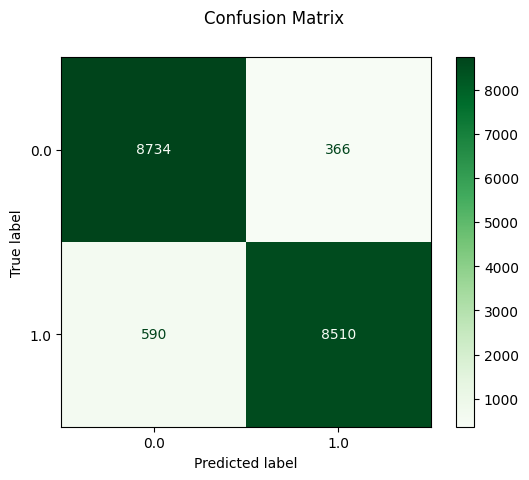

In [ ]:
disp = metrics.ConfusionMatrixDisplay.from_estimator(
    ModelBag, test_xs, test_ys, cmap=plt.cm.Greens
)
disp.figure_.suptitle("Confusion Matrix")
plt.show()

The model correctly identifies 8708 Bad clients and 8529 Good clients, showing excellent overall performance.

Low number of False Positives (392):
These are applicants predicted as Good but who are actually Bad.
This is a critical error in credit scoring because it corresponds to giving credit to high-risk clients.
The low number indicates strong precision.

Moderate number of False Negatives (571):
These correspond to Good clients incorrectly flagged as Bad.
Although they do not create financial loss, they represent missed business opportunities.

Balanced performance between classes:
Both classes have similar counts and similar error rates, which indicates that:

- The model is not biased toward one class.

- SMOTE balancing and model training were effective.



## Conclusion

In this project, we developed a full machine-learning pipeline to clean the dataset, engineer meaningful features, and build a predictive model for credit scoring. The work began with an extensive data-cleaning phase: removing invalid values, handling missing data, correcting inconsistent categorical labels, encoding qualitative variables, and treating outliers via percentile-based filtering. We then reconstructed missing values at the customer level and removed remaining incomplete rows to ensure data consistency.

After cleaning, we conducted exploratory analyses using boxplots, correlation matrices, and mutual information. Linear correlations with the target variable were generally weak, which motivated the creation of new financial ratio features (such as Debt-to-Income or Debt-per-Account) and the use of Mutual Information to detect non-linear relationships. Feature selection allowed us to keep only the most informative predictors for modelling.

On the modelling side, we standardized numerical features and addressed class imbalance with SMOTE. We trained several supervised classifiers and optimized their hyperparameters using GridSearchCV. Among all models, the Bagging Classifier provided the strongest predictive performance, with high F1-score, precision, and recall. A bootstrap analysis on the test set confirmed that the model is stable and robust, with narrow confidence intervals across all performance metrics.

Some steps were more challenging. Correlation-based analysis alone could not identify strong predictors. Hyperparameter tuning was computationally expensive due to large grids. With more time, neural network models could be explored as an alternative approach for capturing more complex data patterns.